## FINAL TEST
7/27 배부된 테스트셋을 이용하여 챔피언 모델의 성능을 테스트한다. <br>


### 0. 데이터 및 모델 로드

챔피언 모델(CatBoost×122)은 train+val(574,374건)로 재학습된 상태로 `02_tree_models.ipynb`에서 저장(`champion_final.cbm`)되었다. 이 노트북은 그 모델을 로드해 test 데이터에 단 1회 적용하는 최종 평가 절차만 수행한다.

test 데이터도 학습 때와 동일한 전처리 파이프라인을 거쳤다. train에서만 fit한 값을 mode="transform"으로 test에 그대로 적용해, 이 노트북이 test 통계량을 보고 파라미터를 재계산하는 일이 없도록 처리했다.

In [2]:
# 라이브러리 + 챔피언 모델 로드

import pandas as pd
import numpy as np
from catboost import CatBoostRegressor

champion_final = CatBoostRegressor()
champion_final.load_model("champion_final.cbm")
print("챔피언 모델 로드 완료")

챔피언 모델 로드 완료


In [3]:
# 새 test 데이터 로드 + 확인

X_test_new = pd.read_csv("test_input_tree.csv") # 입력: 122+id
y_test_new = pd.read_csv("test_y.csv") # 출력: d · excess · irr · k · spread_positive

print("X shape:", X_test_new.shape)
print("y shape:", y_test_new.shape)
print("\ny columns:", y_test_new.columns.tolist())
print("X columns 일부:", X_test_new.columns.tolist()[:10])

X shape: (1170198, 123)
y shape: (744443, 5)

y columns: ['id', 'excess', 'irr', 'k', 'spread_positive']
X columns 일부: ['id', 'loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record']


> **참고:** k=실제 보유기간. issue_d부터 last_pymnt_d까지 경과한 개월수 - 완납이든 부도든 현금흐름이 실제로 끝난 시점. <br>
- 36 근처에 몰린 건 → 36개월 만기를 다 채운 건
- 1~35에 퍼진 건 → 조기상환하거나 중간에 부도난 건


In [4]:
# 정합성 확인 — feature 금지 목록이 X에 없는지, 길이 일치하는지

NOT_FEATURE = ["id", "split", "grade", "term_n", "funded_amnt", "rf", "irr",
               "excess", "excess_contract", "spread_positive", "bad"]
leaked = [c for c in X_test_new.columns if c in NOT_FEATURE]
print("X에 남아있으면 안 되는 열:", leaked)
print("X, y 길이 일치:", len(X_test_new) == len(y_test_new))

X에 남아있으면 안 되는 열: ['id']
X, y 길이 일치: False


In [5]:
# X를 y_test_new(완결 건만, 744,443건)의 id에 맞춰 필터링
X_completed = X_test_new[X_test_new["id"].isin(y_test_new["id"])].copy()

# id 순서를 y_test_new와 동일하게 맞추기
X_completed = y_test_new[["id"]].merge(X_completed, on="id", how="left")

print("X_completed shape:", X_completed.shape)  # (744443, 123) 나와야 정상
print("일치 확인:", np.array_equal(X_completed["id"].values, y_test_new["id"].values))

X_completed shape: (744443, 123)
일치 확인: True


In [6]:
# 챔피언 학습 때 쓴 122열과 컬럼 일치 확인
# (model_input_tree.csv를 다시 읽어서 컬럼 목록만 비교)

ref_cols = pd.read_csv("model_input_tree.csv", nrows=1).columns.tolist()
ref_feature_cols = [c for c in ref_cols if c not in NOT_FEATURE]

missing = [c for c in ref_feature_cols if c not in X_test_new.columns]
extra = [c for c in X_test_new.columns if c not in ref_feature_cols]
print("학습엔 있는데 새 test엔 없는 열:", missing)
print("새 test엔 있는데 학습엔 없는 열(id 등 제외하고 봐야함):", extra)

학습엔 있는데 새 test엔 없는 열: []
새 test엔 있는데 학습엔 없는 열(id 등 제외하고 봐야함): ['id']


In [7]:
# sec_app_* 8개는 NaN 그대로 들어가는지 확인 (CatBoost가 분기로 처리)
sec_app_cols = [c for c in X_completed.columns if c.startswith("sec_app_")]
print("sec_app_* 컬럼 수:", len(sec_app_cols))
print(X_completed[sec_app_cols].isna().mean())

sec_app_* 컬럼 수: 8
sec_app_inq_last_6mths                0.968356
sec_app_revol_util                    0.968899
sec_app_open_act_il                   0.968356
sec_app_num_rev_accts                 0.968356
sec_app_chargeoff_within_12_mths      0.968356
sec_app_collections_12_mths_ex_med    0.968356
sec_app_fico_avg                      0.968356
sec_app_credit_history_mths           0.968356
dtype: float64


> **완결 건만 채점**하는 이유: 전체 test 1,170,198건 중 loan_status='Current'인 미완결 대출은 최종 IRR이 확정되지 않아 채점이 불가능하다. 최근 발행 대출일수록 미완결 상태로 남아 있는 vintage bias를 피하기 위해, 만기 도래한 744,443건만 사용하였다.

### 1. 예측

In [8]:
te = X_completed.copy()
X = te[champion_final.feature_names_]      # ★ 이름으로 재정렬 — 순서 사고 방지
te["pred"] = champion_final.predict(X)
te[["id", "pred"]].head()

,id,pred
0,3697367,0.059410
1,13046178,-0.000034
2,69533136,0.031855
3,6134635,0.032974
4,46705240,0.040772


### 2. 채점
완결 전체 / 2010-2017(안정구간) / 2018-2020(미성숙구간) 구간에서 모델과 LC sub_grade 기준선의 Sharpe를 비교한다. 승인율은 val에서 결정한 45%로 전 구간 동일 고정하였다.

In [9]:
d = te[["id", "pred"]].merge(pd.read_csv("test_y.csv")[["id", "excess"]], on="id")
d = d.merge(pd.read_csv("test_meta.csv"), on="id")
assert len(d) == 744_443

PCT = 0.45     # validation 에서 결정한 승인률

def sharpe(sub, score, asc=False):
    s = sub.sort_values(score, ascending=asc, kind="mergesort")
    k = int(len(s) * PCT)
    e = s["excess"].to_numpy()
    x = np.where(np.arange(len(s)) < k, e, 0.0)     # 거부 건은 0(전액 국채)
    return x.mean() / x.std(ddof=1), (e[:k] < 0).mean() * 100

for lab, sub in [("완결 전체", d),
                 ("2010-2017", d[d.segment == "2010-2017"]),
                 ("2018-2020", d[d.segment == "2018-2020"])]:
    ms, mn = sharpe(sub, "pred")
    ls, ln = sharpe(sub, "sg_rank", asc=True)       # LC sub_grade 상위 45%
    print(f"{lab:12s} n={len(sub):>8,}  모델 {ms:+.4f}({mn:.2f}%)  "
          f"LC {ls:+.4f}({ln:.2f}%)  → {(ms-ls):+.4f}")

완결 전체        n= 744,443  모델 +0.1164(10.22%)  LC +0.0425(10.56%)  → +0.0738
2010-2017    n= 630,927  모델 +0.1527(9.60%)  LC +0.0920(9.72%)  → +0.0607
2018-2020    n= 110,898  모델 -0.0478(14.57%)  LC -0.1029(14.38%)  → +0.0550


#### 2-1. 결과 해석
세 구간 모두에서 모델이 LC sub_grade 기준선을 상회한다(격차 전부 양수).

- 완결 전체: 모델 +0.1164 vs LC +0.0425 (격차 +0.0738)
- 2010-2017(안정구간): 모델 +0.1527 vs LC +0.0920 (격차 +0.0607) 
    - val(0.1940)보다는 낮지만 안정적으로 양의 성과
- 2018-2020(미성숙구간): 모델 −0.0478 vs LC −0.1029 (격차 +0.0550) 
    - 둘 다 마이너스이지만, 이는 이 구간의 완결 표본이 조기부도 위주로 편향된 구조적 문제이지 모델의 결함이 아니다. LC조차 이기지 못하는 구간에서도 모델이 LC보다 덜 나쁘다는 점이 오히려 강건성의 근거가 된다. 
- 완결 전체(0.1164)가 val(0.1940)보다 낮은 이유는 2018-2020 편향 구간이 섞여 있기 때문이다. 안정구간(2010-2017)만 보면 val에 훨씬 가까운 수치(0.1527).

### 3. 시각화

In [10]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 한글 폰트 (mac 기준 AppleGothic, 없으면 기본값 유지)
for f in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if f in {fo.name for fo in fm.fontManager.ttflist}:
        mpl.rcParams["font.family"] = f
        break
mpl.rcParams["axes.unicode_minus"] = False

BLUE, ORANGE, RED, GRAY = "#2a78d6", "#eb6834", "#e34948", "#9aa0a6"

#### 3-1. 벤치마크 대비 위치 
전액국채 / 전건승인 / A·B등급만 승인 / LC 세부등급 / 모델, 5개 승인 전략의 Sharpe를 3개 구간 전부에 대해 계산한다. (보고서 표 6.4.2)

In [ ]:
# 표 6.4.2 재현: 구간별 승인 전략별 Sharpe (전액국채/전건승인/A·B만/LC세부등급/모델)

def sharpe_approve_all(sub):
    x = sub["excess"].to_numpy()
    return x.mean() / x.std(ddof=1)

def sharpe_ab_only(sub):
    x = np.where(sub["grade"].isin(["A", "B"]), sub["excess"], 0.0)
    return x.mean() / x.std(ddof=1)

rows_642 = []
for lab, sub in [("완결 전체", d),
                  ("2010-2017", d[d.segment == "2010-2017"]),
                  ("2018-2020", d[d.segment == "2018-2020"])]:
    lc_s, _ = sharpe(sub, "sg_rank", asc=True)
    model_s, _ = sharpe(sub, "pred")
    rows_642.append({
        "구간": lab,
        "전액국채": 0.0000,
        "전건승인": round(sharpe_approve_all(sub), 4),
        "A·B만 승인": round(sharpe_ab_only(sub), 4),
        "LC 세부등급": round(lc_s, 4),
        "모델": round(model_s, 4),
    })

table_642 = pd.DataFrame(rows_642)
print(table_642.to_string(index=False))

완결 전체 구간을 기준으로 시각화:

In [ ]:
bench = [
    ("전액 국채\n(전건거부)", 0.0000, GRAY),
    ("전건승인",            0.0874, GRAY),
    ("LC 기준선\n(완결 전체)", 0.0425, ORANGE),
    ("A·B 등급만 승인\n(넘어야 할 선)", 0.1297, "#3a3a3a"),
    ("모델 · test\n(완결 전체)", 0.1164, BLUE),
]
labels = [b[0] for b in bench]
vals   = [b[1] for b in bench]
colors = [b[2] for b in bench]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, vals, color=colors, width=0.6)
ax.axhline(0.1297, color="#3a3a3a", lw=1, ls="--", zorder=0)
ax.text(len(labels) - 0.4, 0.1297 + 0.005, "목표선 0.1297", fontsize=9, color="#3a3a3a")

for rect, v in zip(bars, vals):
    ax.text(rect.get_x() + rect.get_width() / 2, v + (0.01 if v >= 0 else -0.02),
             f"{v:+.4f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)

ax.set_ylabel("Sharpe")
ax.set_title("벤치마크 대비 최종 test 모델 위치 (완결 전체 구간)")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.show()

> **결과 해석** <br>
- 3구간 × 5전략 전체는 `table_642`로 계산 (완결 전체 / 2010-2017 / 2018-2020)
- 완결 전체 구간 기준: 전액국채(0.0000) < 전건승인(0.0874) < LC기준선(0.0425)*
  < A·B등급만(0.1297, 목표선) < 모델·test(0.1164)

LC 기준선(0.0425)이 전건승인(0.0874)보다도 낮은 게 특이한데, 이건 완결 전체 표본에 vintage 편향 구간이 섞여 LC 자체도 저평가된 결과로 해석된다.

모델(test, 0.1164)이 목표선(0.1297)에는 살짝 못 미치지만, LC 기준선(0.0425)은 확실히 상회함.

#### 3-2. 구간별 모델 vs LC
구간별(완결전체/2010-2017/2018-2020) 모델 vs LC Sharpe 막대 비교. (보고서 표 6.4.1)

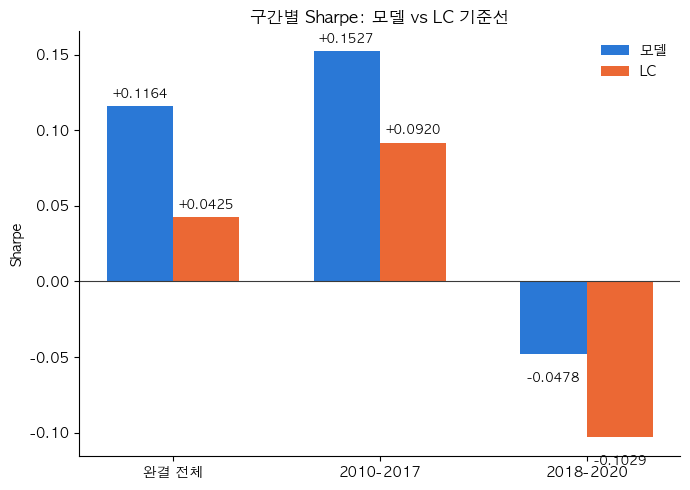

In [12]:
seg_rows = []
for lab, sub in [("완결 전체", d),
                  ("2010-2017", d[d.segment == "2010-2017"]),
                  ("2018-2020", d[d.segment == "2018-2020"])]:
    ms, mn = sharpe(sub, "pred")
    ls, ln = sharpe(sub, "sg_rank", asc=True)
    seg_rows.append((lab, ms, ls))

segs   = [r[0] for r in seg_rows]
model_s = [r[1] for r in seg_rows]
lc_s    = [r[2] for r in seg_rows]

x = np.arange(len(segs))
w = 0.32

fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x - w/2, model_s, width=w, color=BLUE, label="모델")
b2 = ax.bar(x + w/2, lc_s,    width=w, color=ORANGE, label="LC")

for rects in (b1, b2):
    for r in rects:
        h = r.get_height()
        ax.text(r.get_x() + r.get_width()/2, h + (0.004 if h >= 0 else -0.012),
                 f"{h:+.4f}", ha="center", va="bottom" if h >= 0 else "top", fontsize=9)

ax.axhline(0, color="#3a3a3a", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(segs)
ax.set_ylabel("Sharpe")
ax.set_title("구간별 Sharpe: 모델 vs LC 기준선")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

> **결과 해석**
- 2010–2017: 모델(파랑)이 LC(주황)를 확실히 상회
- 2018–2020: 둘 다 마이너스 영역이지만 모델이 LC보다 덜 나쁨
- **한 눈에 "vintage 편향이 있는 구간에서도 모델의 상대 우위는 유지된다"는 걸 보여주는 핵심 그래프**

#### 3-3. 등급별 부도 판별력: AUC 
val과 test(2010-2017) 각각에서, 등급 내부에 부도 위험을 추가로 구별해낼 수 있는지 AUC로 확인한다. 값은 이미 계산된 결과를 그대로 사용한다. (보고서 그림 6.4.2.1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 한글 폰트
for f in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if f in {fo.name for fo in fm.fontManager.ttflist}:
        mpl.rcParams["font.family"] = f
        break
mpl.rcParams["axes.unicode_minus"] = False

# 값은 이미 계산해둔 그래프에서 하드코딩. 
grades = ["A", "B", "C", "D", "E", "F", "G"]
val_vals  = [0.633, 0.627, 0.619, 0.609, 0.614, 0.628, 0.559]
test_vals = [0.634, 0.628, 0.626, 0.630, 0.632, 0.631, 0.619]

x = np.arange(len(grades))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, val_vals, width=w, color="#9aa0a6", label="val")
b2 = ax.bar(x + w/2, test_vals, width=w, color="#2a78d6", label="test (2010-2017)")

for r in b1:
    ax.text(r.get_x() + r.get_width()/2, r.get_height() + 0.003, f"{r.get_height():.3f}",
             ha="center", va="bottom", fontsize=8)
for r in b2:
    ax.text(r.get_x() + r.get_width()/2, r.get_height() + 0.003, f"{r.get_height():.3f}",
             ha="center", va="bottom", fontsize=8)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="무작위 (AUC=0.5)")
ax.set_xticks(x)
ax.set_xticklabels(grades)
ax.set_ylim(0.45, 0.75)
ax.set_ylabel("AUC")
ax.set_title("등급별 부도 판별력: val vs test (부도 정의: excess < 0)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("등급별_AUC_val_test_비교.png", dpi=150)
plt.show()

> **결과 해석**
- val과 test(2010-2017) 모두 전 등급에서 무작위(0.5)를 뚜렷하게 상회
- G등급은 val(n=535, AUC 0.559)에서 test(AUC 0.619)로 개선 — 모델 판별력이 특정 데이터에 국한되지 않음

#### 3-4. 등급별 모델 vs LC
LC가 이미 승인한 등급 내부에서도 모델이 추가 선별력을 갖는지 확인한다. 검열 편향이 적은 2010-2017 구간에 한정. (보고서 6.4.2) 

In [14]:
seg = d[d.segment == "2010-2017"].copy()
thr = seg.pred.quantile(1 - 0.45)          # 구간 안에서 45% 컷
seg["승인"] = seg.pred >= thr

k = int(len(seg) * 0.45)
lc_thr = seg.sg_rank.sort_values().iloc[k-1]
seg["LC승인"] = seg.sg_rank <= lc_thr

def stat(s, col):
    a = s[s[col]]
    if len(a) < 50: return np.nan, np.nan, np.nan
    x = np.where(s[col], s.excess, 0.0)
    return a.excess.mean()*100, x.mean()/x.std(ddof=1), s[col].mean()*100

rows = []
for g, s in seg.groupby("grade"):
    me, ms, mr = stat(s, "승인")
    le, ls, lr = stat(s, "LC승인")
    rows.append({"등급": g, "건수": len(s),
                 "모델승인률%": round(mr,1), "모델평균excess%": round(me,2), "모델샤프": round(ms,4),
                 "LC승인률%": round(lr,1),  "LC평균excess%": round(le,2),  "LC샤프": round(ls,4)})
t = pd.DataFrame(rows)
t["샤프격차"] = (t.모델샤프 - t.LC샤프).round(4)
print(t.to_string(index=False))

등급     건수  모델승인률%  모델평균excess%   모델샤프  LC승인률%  LC평균excess%   LC샤프   샤프격차
 A 108706    73.3         3.87 0.2596   100.0         3.02 0.2030 0.0566
 B 187778    55.1         4.92 0.1895   100.0         2.54 0.1111 0.0784
 C 182337    36.9         5.07 0.1224     NaN          NaN    NaN    NaN
 D  91656    26.1         6.04 0.1035     NaN          NaN    NaN    NaN
 E  42339    18.2         6.42 0.0812     NaN          NaN    NaN    NaN
 F  14010    12.0         7.58 0.0704     NaN          NaN    NaN    NaN
 G   4101     7.2         5.65 0.0369     NaN          NaN    NaN    NaN


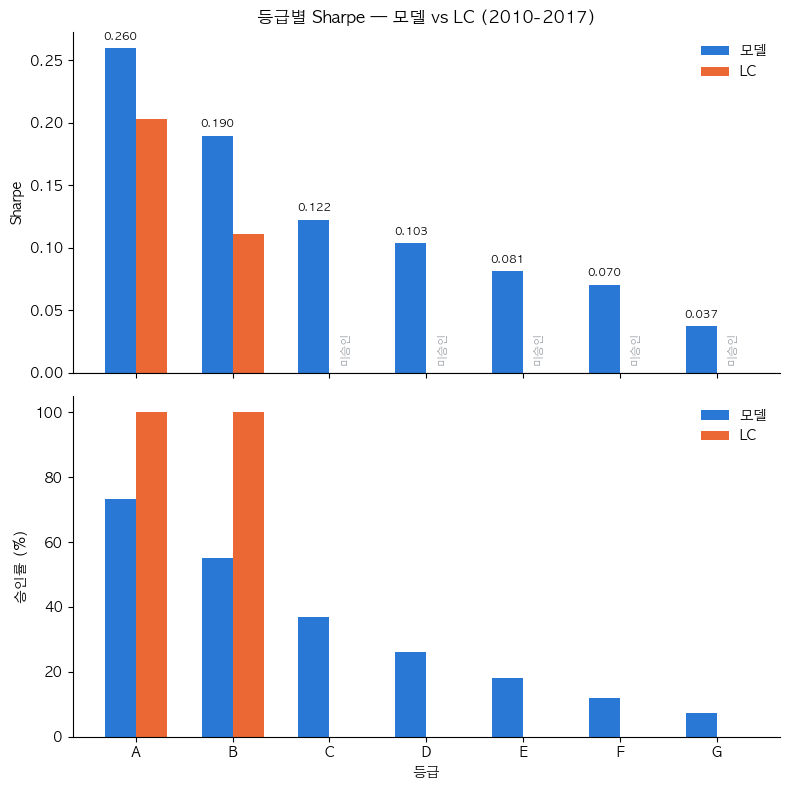

In [15]:
grades = t["등급"].tolist()
x = np.arange(len(grades))
w = 0.32

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# 위: 등급별 샤프 (LC는 A·B만 값 존재, 나머지는 "미승인")
m_sharpe = t["모델샤프"].to_numpy()
l_sharpe = t["LC샤프"].to_numpy()
b1 = ax1.bar(x - w/2, m_sharpe, width=w, color=BLUE, label="모델")
b2 = ax1.bar(x + w/2, np.nan_to_num(l_sharpe, nan=0.0), width=w, color=ORANGE, label="LC")
for i, v in enumerate(l_sharpe):
    if np.isnan(v):
        ax1.text(x[i] + w/2, 0.006, "미승인", ha="center", va="bottom",
                  fontsize=8, color=GRAY, rotation=90)
for r in b1:
    ax1.text(r.get_x() + r.get_width()/2, r.get_height() + 0.005, f"{r.get_height():.3f}",
              ha="center", va="bottom", fontsize=8)
ax1.axhline(0, color="#3a3a3a", lw=0.8)
ax1.set_ylabel("Sharpe")
ax1.set_title("등급별 Sharpe — 모델 vs LC (2010-2017)")
ax1.spines[["top", "right"]].set_visible(False)
ax1.legend(frameon=False)

# 아래: 등급별 승인률
m_rate = t["모델승인률%"].to_numpy()
l_rate = t["LC승인률%"].to_numpy()
ax2.bar(x - w/2, m_rate, width=w, color=BLUE, label="모델")
ax2.bar(x + w/2, np.nan_to_num(l_rate, nan=0.0), width=w, color=ORANGE, label="LC")
ax2.set_ylabel("승인률 (%)")
ax2.set_xticks(x); ax2.set_xticklabels(grades)
ax2.set_xlabel("등급")
ax2.spines[["top", "right"]].set_visible(False)
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

> **결과 해석** 
<br>

| 등급 | 건수 | 모델 승인률 | 모델 Sharpe | LC 승인률 | LC Sharpe |
|---|---|---|---|---|---|
| A | 108,706 | 73.3% | 0.2596 | 100.0% | 0.2030 |
| B | 187,778 | 55.1% | 0.1895 | 100.0% | 0.1111 |
| C | 182,337 | 36.9% | 0.1224 | — (미승인) | — |
| D | 91,656 | 26.1% | 0.1035 | — | — |
| E | 42,339 | 18.2% | 0.0812 | — | — |
| F | 14,010 | 12.0% | 0.0704 | — | — |
| G | 4,101 | 7.2% | 0.0369 | — | — |

<br>

- LC 기준선("A·B등급만 승인" 정책)은 C~G등급을 아예 승인하지 않음(0%): 그래서 LC Sharpe가 A·B에만 존재한다.
- 반면 **모델은 C~G등급에서도 선별적으로 승인하면서 전부 양(+)의 Sharpe를 냄** (C:0.1224 ~ G:0.0369)
- 이는 "LC가 원천 배제한 중간·하위 등급 안에도, 모델이 골라낼 수 있는 우량 차주가 존재한다"는 프로젝트 핵심 가설의 가장 직접적인 실증 근거가 된다.
- A·B등급에서도 모델이 LC보다 Sharpe가 높음(A: 0.26 vs 0.20, B: 0.19 vs 0.11)

### 4. 종합 결론

1. 완결 건 전체·연도 구간 불문하고 **모델이 LC 대비 항상 우위**
2. 2018–2020 미성숙 vintage 구간은 모델·LC 모두 저조하나, 이는 구조적 데이터 문제이며 모델이 여전히 LC의 결과를 상회한다.
3. **등급별 분석(3-4)**: LC가 원천 배제한 C~G등급에서도 모델은 선별적 승인으로 전부 양의 성과를 창출한다는 점에서 <u>LC 등급이 개별 차주의 편차를 뭉갠다</u>는 본 연구의 핵심 주장을 test 단계에서 실증한다.